In [1]:
import pandas as pd

X_train, y_train, y_train_index <br>
X_test_reduced, y_test_reduced, y_test_index_reduced <br>


In [15]:
X_train = pd.read_parquet("X_train.parquet")
X_train.head()

value  period
id time                  
0  0    -0.783992       1
   1    -0.414595       1
   2     1.674117       1
   3     1.575443       1
   4    -0.520342       1

In [27]:
# print out properties and meanings of this dataset
print("index names:", X_train.index.names)
print("example ids:", X_train.index.get_level_values("id").unique()[:10].tolist())
print("example times:", X_train.index.get_level_values("time")[:10].tolist())
print("period values:", X_train["period"].unique())
print("shape:", X_train.shape)

# find how many unique ids and times there are
num_unique_ids = X_train.index.get_level_values("id").nunique()
num_unique_times = X_train.index.get_level_values("time").nunique()
print("number of unique ids:", num_unique_ids)
print("number of unique times:", num_unique_times)

# unique ids range
print("unique ids range:", X_train.index.get_level_values("id").min(), "to", X_train.index.get_level_values("id").max())

index names: ['id', 'time']
example ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
example times: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
period values: [1 2]
shape: (35036464, 2)
number of unique ids: 10000
number of unique times: 5962
unique ids range: 0 to 9999


In [11]:
X_test_reduced = pd.read_parquet("X_test.reduced.parquet")
X_test_reduced.head()

value  period
id    time                  
10000 0     0.746051       1
      1     0.318003       1
      2    -0.261702       1
      3     2.108140       1
      4    -0.192362       1

In [28]:
print("index names:", X_test_reduced.index.names)
print("example ids:", X_test_reduced.index.get_level_values("id").unique()[:10].tolist())
print("example times:", X_test_reduced.index.get_level_values("time")[:10].tolist())
print("period values:", X_test_reduced["period"].unique())
print("shape:", X_test_reduced.shape)

# find how many unique ids and times there are
num_unique_ids = X_test_reduced.index.get_level_values("id").nunique()
num_unique_times = X_test_reduced.index.get_level_values("time").nunique()
print("number of unique ids:", num_unique_ids)
print("number of unique times:", num_unique_times)

print("unique ids range:", X_test_reduced.index.get_level_values("id").min(), "to", X_test_reduced.index.get_level_values("id").max())

index names: ['id', 'time']
example ids: [10000, 10001, 10002, 10003, 10004, 10005, 10006, 10007, 10008, 10009]
example times: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
period values: [1 2]
shape: (346019, 2)
number of unique ids: 100
number of unique times: 5926
unique ids range: 10000 to 10099


### y_train — per-timestep target over the online segment

In [29]:
y_train = pd.read_parquet("y_train.parquet")
y_train.head()

target
id time        
0  1192       0
   1193       0
   1194       0
   1195       0
   1196       0

In [30]:
print("index names:", y_train.index.names)
print("columns:", y_train.columns.tolist())
print("shape:", y_train.shape)
print("target values:", y_train["target"].unique())

# one row per (id, time) — but only for the ONLINE segment (period == 2)
print("number of unique ids:", y_train.index.get_level_values("id").nunique())
print("unique ids range:", y_train.index.get_level_values("id").min(),
      "to", y_train.index.get_level_values("id").max())

# target is the running "has a break occurred yet" flag: 0 before the break, 1 from the break onward
print("overall target mean (fraction of online steps that are post-break):", round(y_train["target"].mean(), 4))
print("rows in y_train vs X_train period==2 rows:", len(y_train), "vs", int((X_train["period"] == 2).sum()))

index names: ['id', 'time']
columns: ['target']
shape: (5036517, 1)
target values: [0 1]
number of unique ids: 10000
unique ids range: 0 to 9999
overall target mean (fraction of online steps that are post-break): 0.2557
rows in y_train vs X_train period==2 rows: 5036517 vs 5036517


### y_train_index — one row per series: the break location

In [31]:
y_train_index = pd.read_parquet("y_train_index.parquet")
y_train_index.head()

,tau_index,tau
id,,
0,72,1264
1,-1,-1
2,-1,-1
3,-1,-1
4,-1,-1


In [32]:
print("index names:", y_train_index.index.names)   # one row per series (no `time` level)
print("columns:", y_train_index.columns.tolist())
print("shape:", y_train_index.shape)

# tau       = absolute `time` of the true structural break (-1 = no break in this series)
# tau_index = offset of the break INTO the online segment (tau = boundary_time + tau_index)
no_break = int((y_train_index["tau"] == -1).sum())
print("no-break series (tau == -1):", no_break)
print("break series:", len(y_train_index) - no_break)
print("break rate:", round((y_train_index["tau"] != -1).mean(), 4))

# where inside the online segment do breaks happen?
breaks = y_train_index[y_train_index["tau"] != -1]
print("tau_index (break offset into online): min", breaks["tau_index"].min(),
      "median", int(breaks["tau_index"].median()), "max", breaks["tau_index"].max())

index names: ['id']
columns: ['tau_index', 'tau']
shape: (10000, 2)
no-break series (tau == -1): 5033
break series: 4967
break rate: 0.4967
tau_index (break offset into online): min 0 median 184 max 984


### Reduced test labels (local evaluation set)

`y_test_reduced` and `y_test_index_reduced` are the labels for the 100-series local eval set (ids 10000–10099). They mirror `y_train` / `y_train_index` and let you score predictions offline before submitting.

In [33]:
y_test_reduced = pd.read_parquet("y_test.reduced.parquet")
y_test_reduced.head()

target
id    time        
10000 3312       0
      3313       0
      3314       0
      3315       0
      3316       0

In [34]:
print("index names:", y_test_reduced.index.names)
print("columns:", y_test_reduced.columns.tolist())
print("shape:", y_test_reduced.shape)
print("target values:", y_test_reduced["target"].unique())
print("unique ids range:", y_test_reduced.index.get_level_values("id").min(),
      "to", y_test_reduced.index.get_level_values("id").max())

# same link as train: y covers exactly the online (period==2) rows of X
print("rows vs X_test_reduced period==2:", len(y_test_reduced), "vs", int((X_test_reduced["period"] == 2).sum()))

index names: ['id', 'time']
columns: ['target']
shape: (50983, 1)
target values: [0 1]
unique ids range: 10000 to 10099
rows vs X_test_reduced period==2: 50983 vs 50983


In [35]:
y_test_index_reduced = pd.read_parquet("y_test_index.reduced.parquet")
y_test_index_reduced.head()

,tau_index,tau
id,,
10000,-1,-1
10001,-1,-1
10002,13,1481
10003,-1,-1
10004,391,2775


In [36]:
print("index names:", y_test_index_reduced.index.names)   # one row per series
print("columns:", y_test_index_reduced.columns.tolist())
print("shape:", y_test_index_reduced.shape)
print("break rate:", round((y_test_index_reduced["tau"] != -1).mean(), 4))
print("unique ids range:", y_test_index_reduced.index.get_level_values("id").min(),
      "to", y_test_index_reduced.index.get_level_values("id").max())

index names: ['id']
columns: ['tau_index', 'tau']
shape: (100, 2)
break rate: 0.53
unique ids range: 10000 to 10099


### How the datasets connect

Each `id` is one time series, split into two consecutive segments by the **period** column:
- `period == 1` → historical **reference** segment (given up front)
- `period == 2` → **online** segment, revealed one observation at a time

The boundary is where `period` switches 1 → 2; its `time` equals the length of the reference segment.

- **X_*** holds the raw series (`value`, `period`) for every `(id, time)`.
- **y_*_index** holds one row per series: `tau` = absolute time of the true break (`-1` = no break), `tau_index` = its offset into the online segment, so `tau = boundary_time + tau_index`.
- **y_*** holds the per-timestep target over the **online** segment only: `target = 1` once `time >= tau`, else `0`. No-break series are all `0`.

In [ ]:
# Walk through one break series end to end
sid = 0
xi = X_train.loc[sid]
boundary_time = int((xi["period"] == 1).sum())   # length of reference segment = first online time
tau = int(y_train_index.loc[sid, "tau"])
tau_index = int(y_train_index.loc[sid, "tau_index"])

print(f"series id={sid}")
print("  reference length (period==1):", boundary_time)
print("  online    length (period==2):", int((xi["period"] == 2).sum()))
print("  boundary time (first period==2 time):", xi[xi["period"] == 2].index.min())
print("  tau:", tau, " tau_index:", tau_index, " -> boundary + tau_index =", boundary_time + tau_index)

# the target for this series flips 0 -> 1 exactly at tau
yi = y_train.loc[sid]
print("  online times run:", yi.index.min(), "to", yi.index.max())
print("  target == 0 for all time <  tau:", bool((yi.loc[yi.index <  tau, "target"] == 0).all()))
print("  target == 1 for all time >= tau:", bool((yi.loc[yi.index >= tau, "target"] == 1).all()))

In [ ]:
# Verify the relationships hold across the whole training set
period2 = X_train["period"] == 2

# 1) boundary_time + tau_index == tau  (for break series)
boundary_time = X_train[~period2].groupby(level="id").size().rename("boundary")  # length of period 1 per id
chk = y_train_index.join(boundary_time)
brk = chk[chk["tau"] != -1]
print("tau == boundary + tau_index for all break series:",
      bool((brk["tau"] == brk["boundary"] + brk["tau_index"]).all()))

# 2) y_train covers exactly the period==2 rows of X_train
print("y_train rows == number of period==2 rows:", len(y_train) == int(period2.sum()))

# 3) no-break series (tau == -1) have target all zero
nobreak_ids = y_train_index.index[y_train_index["tau"] == -1]
nobreak_target_sum = y_train.loc[y_train.index.get_level_values("id").isin(nobreak_ids), "target"].sum()
print("no-break series have target all 0:", bool(nobreak_target_sum == 0))

### Summary — structure & connections

| dataset | grain (index) | columns | meaning |
|---|---|---|---|
| `X_train` / `X_test_reduced` | `(id, time)` | `value`, `period` | raw series; `period` 1 = reference, 2 = online |
| `y_train_index` / `y_test_index_reduced` | `id` | `tau`, `tau_index` | true break: absolute time & offset into online segment (`-1` = no break) |
| `y_train` / `y_test_reduced` | `(id, time)` | `target` | online-only 0/1: has a break occurred by this time? |

**Keys / links**
- `id` joins every table (train ids 0–9999, reduced-test ids 10000–10099).
- boundary time = length of the `period==1` segment = first `period==2` time.
- `tau = boundary_time + tau_index`; `target` flips 0→1 at `time == tau`.
- `y_*` exists only for `period==2` rows — the online segment you must score.

**Task:** at each online `time`, output a confidence in [0, 1] that a break has already happened; scored by ROC AUC over all online `(id, time)` rows.

#### taking one time series as example and plotting it

In [41]:
import matplotlib.pyplot as plt

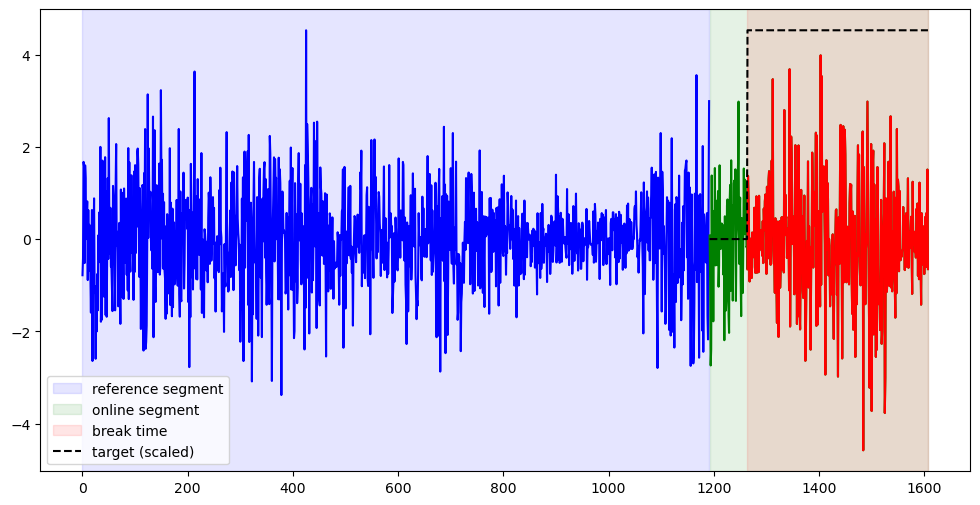

In [72]:
example_id = 0
example_series = X_train.loc[example_id]
targets = y_train.loc[example_id]
tau = y_train_index.loc[example_id, "tau"]
tau_index = y_train_index.loc[example_id, "tau_index"]

# shade online segment green, reference segment blue, break time(if exists) red
# change the line colour to red at the break time (if exists)
reference_times = example_series[example_series["period"] == 1].index
online_times = example_series[example_series["period"] == 2].index


plt.figure(figsize=(12, 6))
plt.axvspan(reference_times.min(), reference_times.max(), color="blue", alpha=0.1, label="reference segment")
plt.axvspan(online_times.min(), online_times.max(), color="green", alpha=0.1, label="online segment")
if tau != -1:
    break_times = example_series.loc[example_series.index.get_level_values("time") >= tau].index
    plt.axvspan(break_times.min(), break_times.max(), color="red", alpha=0.1, label="break time")

# plot the time series data with different colour in different segments
plt.plot(reference_times, example_series.loc[reference_times, "value"], color="blue",)
plt.plot(online_times, example_series.loc[online_times, "value"], color="green")
if tau != -1:
    plt.plot(break_times, example_series.loc[break_times, "value"], color="red")

plt.plot(targets.index, targets["target"] * example_series["value"].max(), color="black", linestyle="--", label="target (scaled)")

plt.legend()
plt.show()

### Construction

For each series `i`, build one feature row per timestep. The **reference** segment (`period == 1`) is used only to compute baseline statistics — it produces no labelled training rows. The **online** segment (`period == 2`) produces the labelled rows, with `target` taken from `y_train`.

`X_train_series_i`

| segment | time | value | feature_1 | … | feature_k | → target |
|---|---|---|---|---|---|---|
| **reference** *(baseline stats only)* | 0 | … | … | … | … | `NA` |
| | 1 | … | … | … | … | `NA` |
| | 2 | … | … | … | … | `NA` |
| | … | | | | | |
| **online** *(labelled rows)* | 1000 | … | … | … | … | `0` |
| | 1001 | … | … | … | … | `0` |
| | … | | | | | |
| **online — after break** (`time ≥ tau`) | 1500 | … | … | … | … | `1` |
| | 1501 | … | … | … | … | `1` |

**Notes**
- `target` is cumulative: `0` before the break, `1` from `tau` onward. No-break series stay `0` for the whole online segment.
- All `feature_*` at time `t` must be **causal** — computable from the reference segment plus online values up to `t` only (no look-ahead), since inference is sequential.
- The boundary (reference → online) length varies per series; `1000` / `1500` here are just illustrative.
